# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer
import math
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import joblib
import shap

# EDA

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shree0910/online-vs-in-store-shopping-behaviour-dataset/online vs store shopping dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [3]:
df.shape
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


# Cek null

In [4]:
df.isnull().sum()

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64

## Cek distribusi label

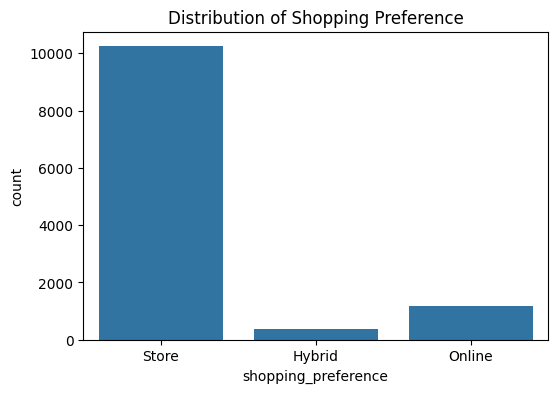

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='shopping_preference', data=df)
plt.title("Distribution of Shopping Preference")
plt.show()

In [6]:
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} unique): {unique_vals}\n")

age (62 unique): [56 69 46 32 60 25 78 38 75 36 40 28 41 70 53 57 20 39 19 61 47 55 77 50
 29 42 66 44 76 59 45 33 79 64 68 72 74 54 24 26 35 21 31 67 43 37 52 34
 23 71 51 27 48 65 62 58 18 22 30 49 73 63]

monthly_income (11504 unique): [221111  96029  19055 ... 154729  66116 168023]

daily_internet_hours (111 unique): [ 6.5  8.2  6.4  6.   7.6  4.9  3.1  7.3  6.8  8.6  1.1  5.8  6.2  3.
  8.4 10.2  8.   5.4  8.5  7.8  5.   4.8  5.7  3.9  7.   8.1  5.2  8.8
  7.4  4.2  9.6  7.1  5.3  4.   6.6  5.1  4.7  5.9  9.4  3.2  4.3  6.1
  4.6  3.7  9.5  3.8  8.3  1.9  7.5 11.8  6.9  7.7  1.5  1.4  8.9  6.7
  8.7  9.1  9.9  5.6 11.   7.2  4.5  3.3  1.   9.3  3.4  9.8  6.3  9.
  5.5  3.6 12.   2.2  7.9 11.2  9.7  2.5  3.5  2.6  2.3  1.2 11.4  2.9
 10.1  4.4  2.1  4.1  2.4  1.8  2.7  9.2 10.8  2.8  2.  10.6 10.3 11.7
 11.1  1.7 10.  10.7 10.5 10.4  1.3 11.5 11.3  1.6 10.9 11.9 11.6]

smartphone_usage_years (14 unique): [12 13  4 11  5  6 10  2  9  7 14  3  8  1]

social_media_hours (61 unique): [

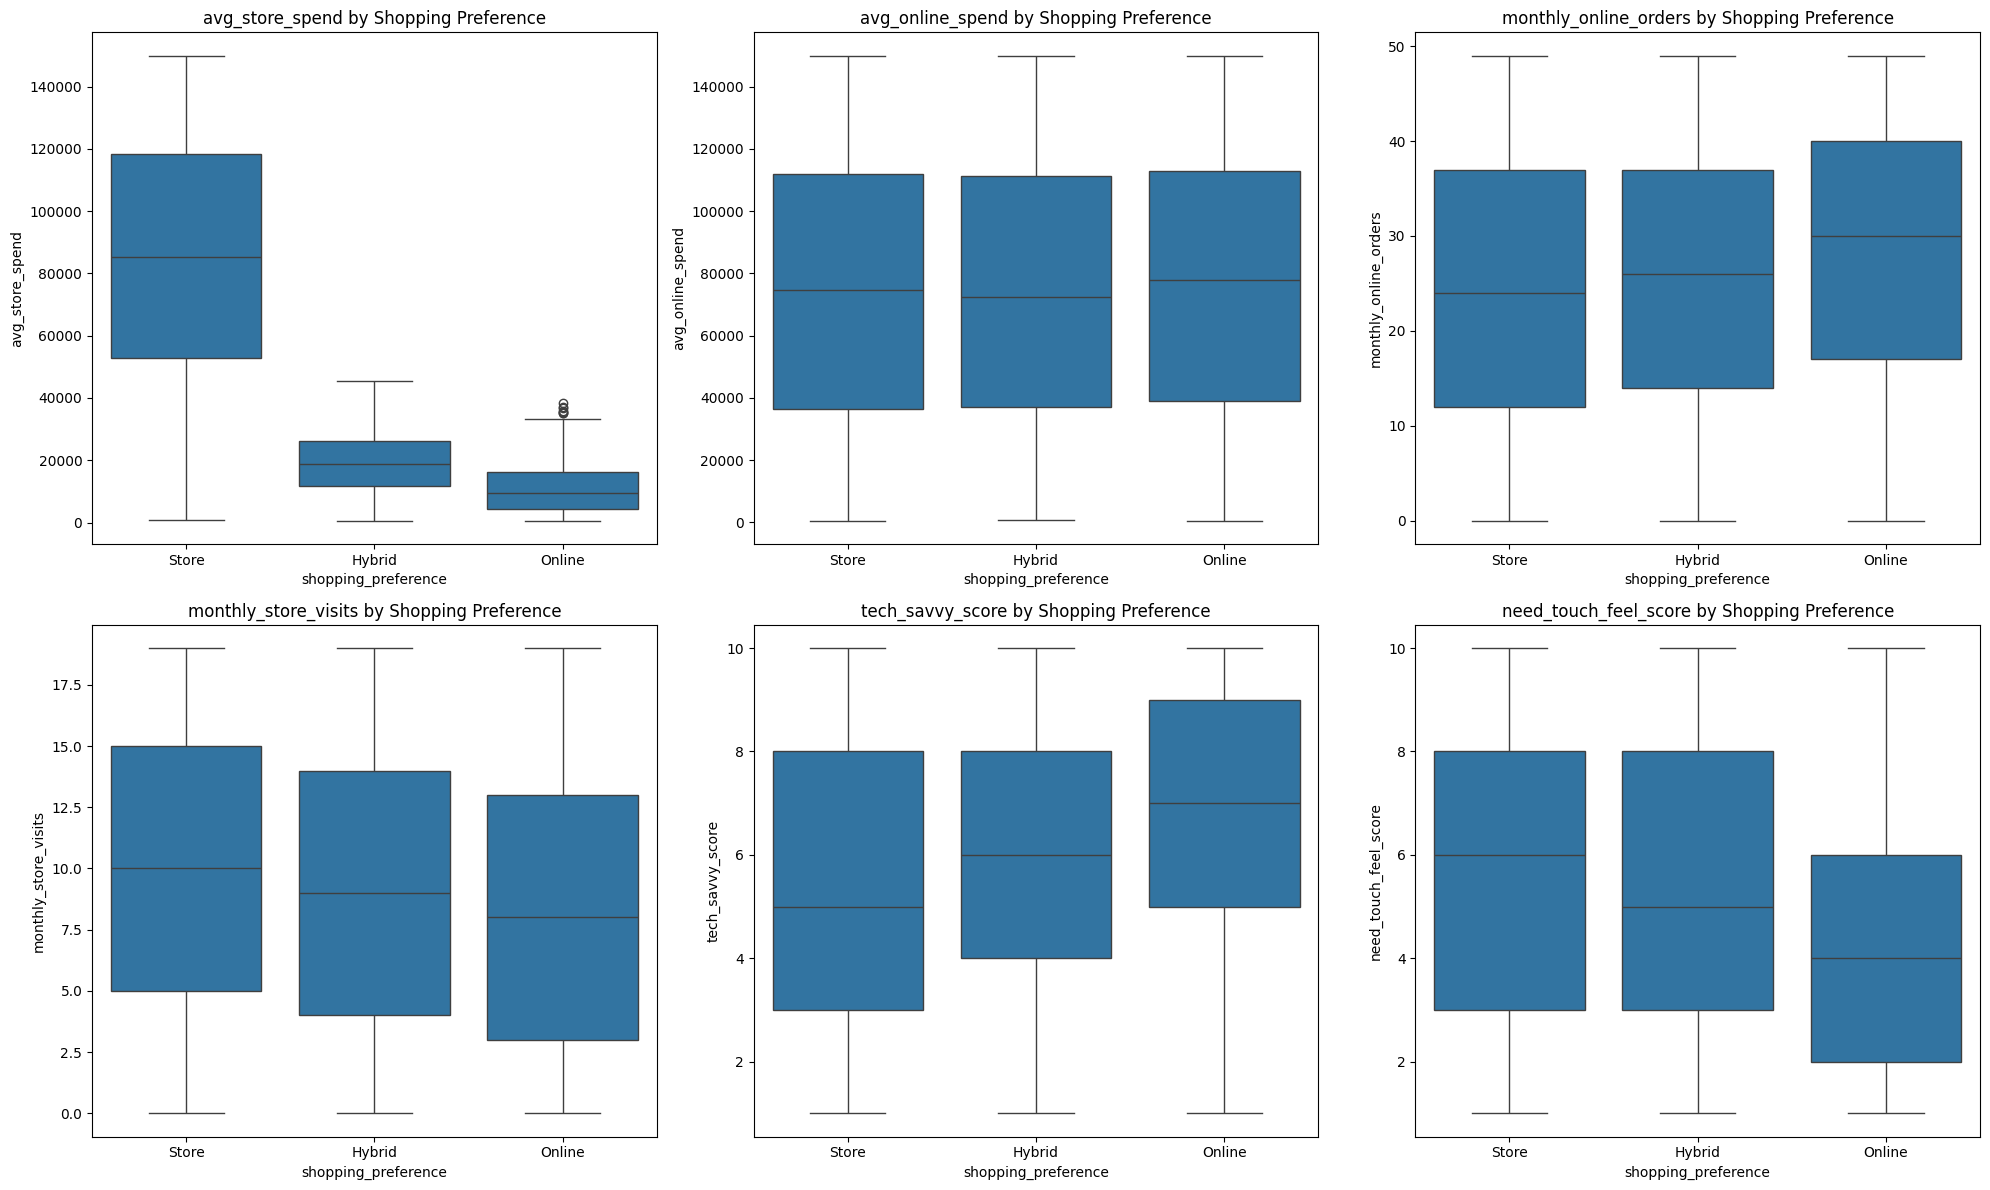

In [7]:
num_cols = ['avg_store_spend', 'avg_online_spend', 'monthly_online_orders', 'monthly_store_visits', 'tech_savvy_score', 'need_touch_feel_score']

plt.figure(figsize=(20,12))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='shopping_preference', y=col, data=df)
    plt.title(f'{col} by Shopping Preference')
plt.tight_layout()
plt.show()

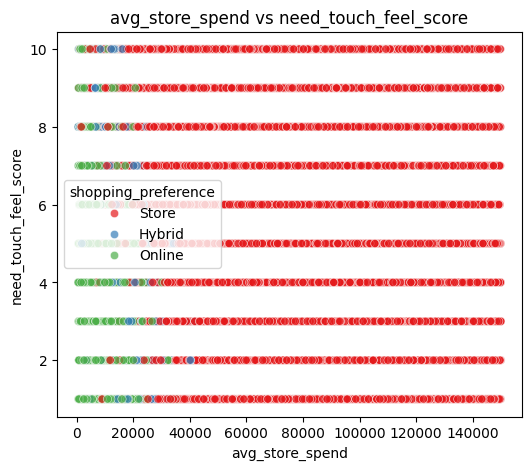

In [8]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='avg_store_spend',
    y='need_touch_feel_score',
    hue='shopping_preference',
    palette='Set1',
    alpha=0.7
)
plt.title('avg_store_spend vs need_touch_feel_score')
plt.show()

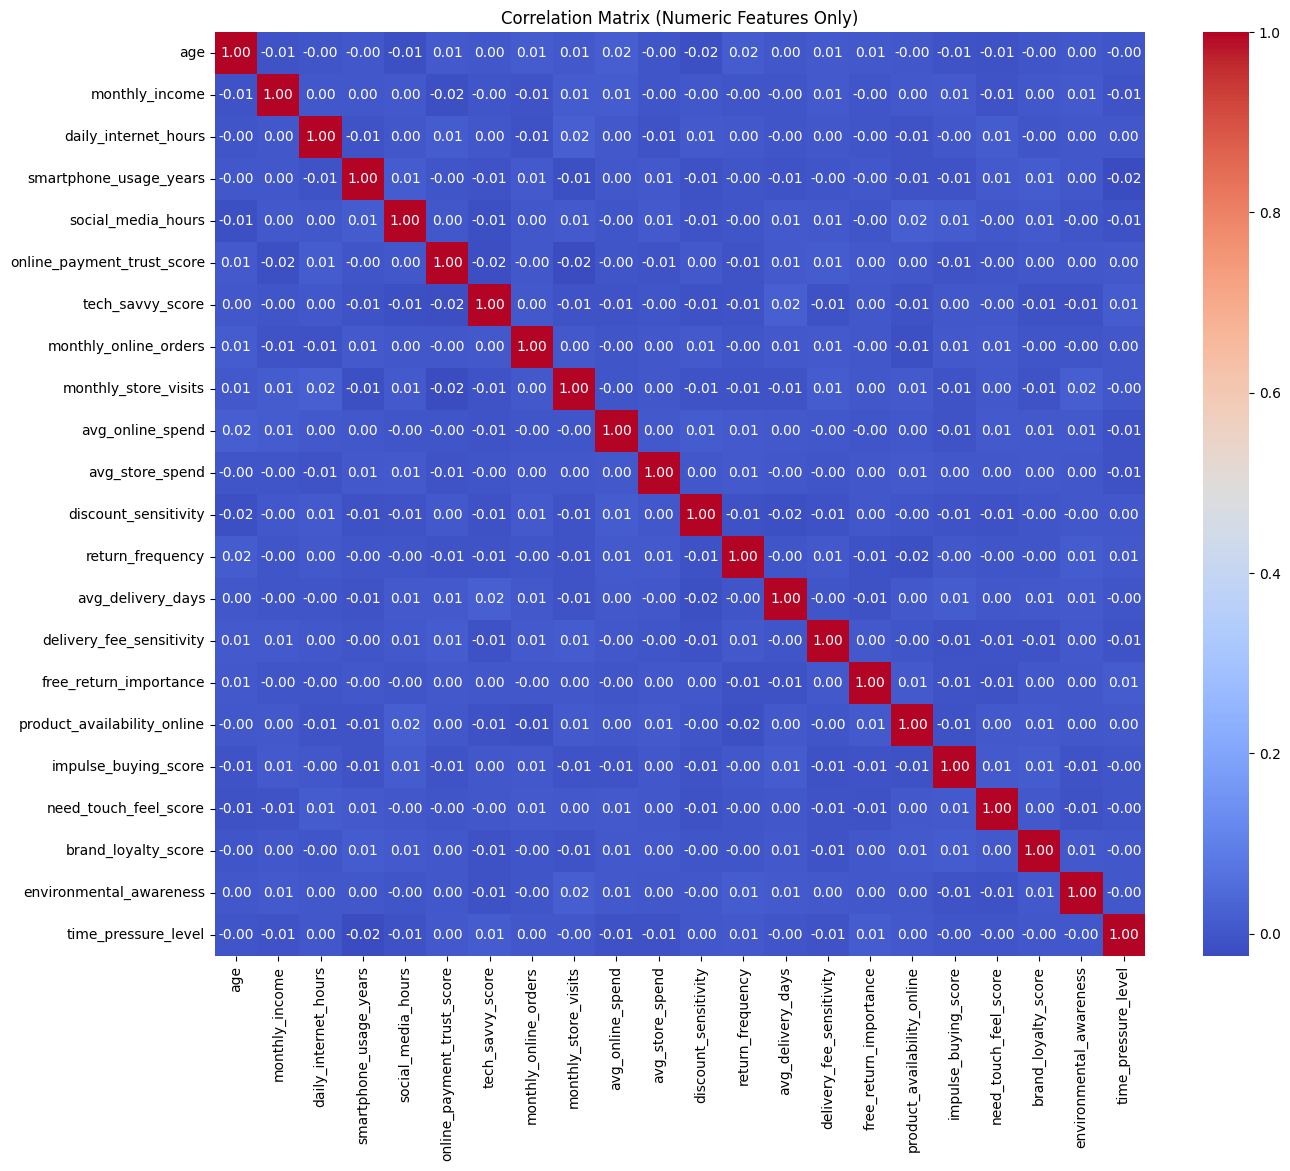

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,12))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

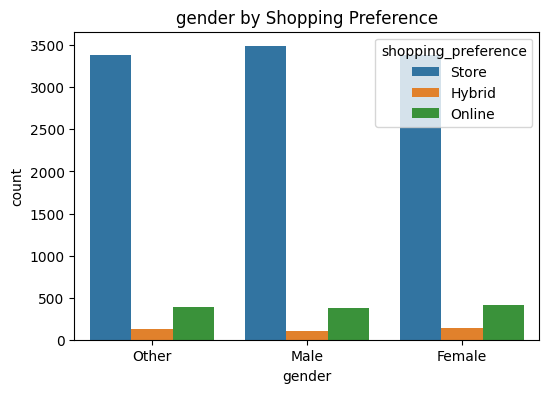

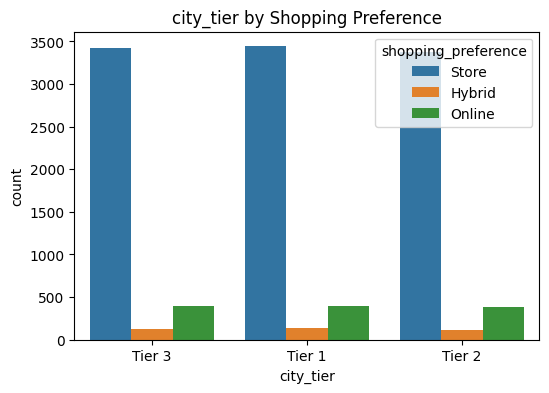

In [10]:
cat_cols = ['gender', 'city_tier']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='shopping_preference', data=df)
    plt.title(f'{col} by Shopping Preference')
    plt.show()

## Cek outlier

In [11]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


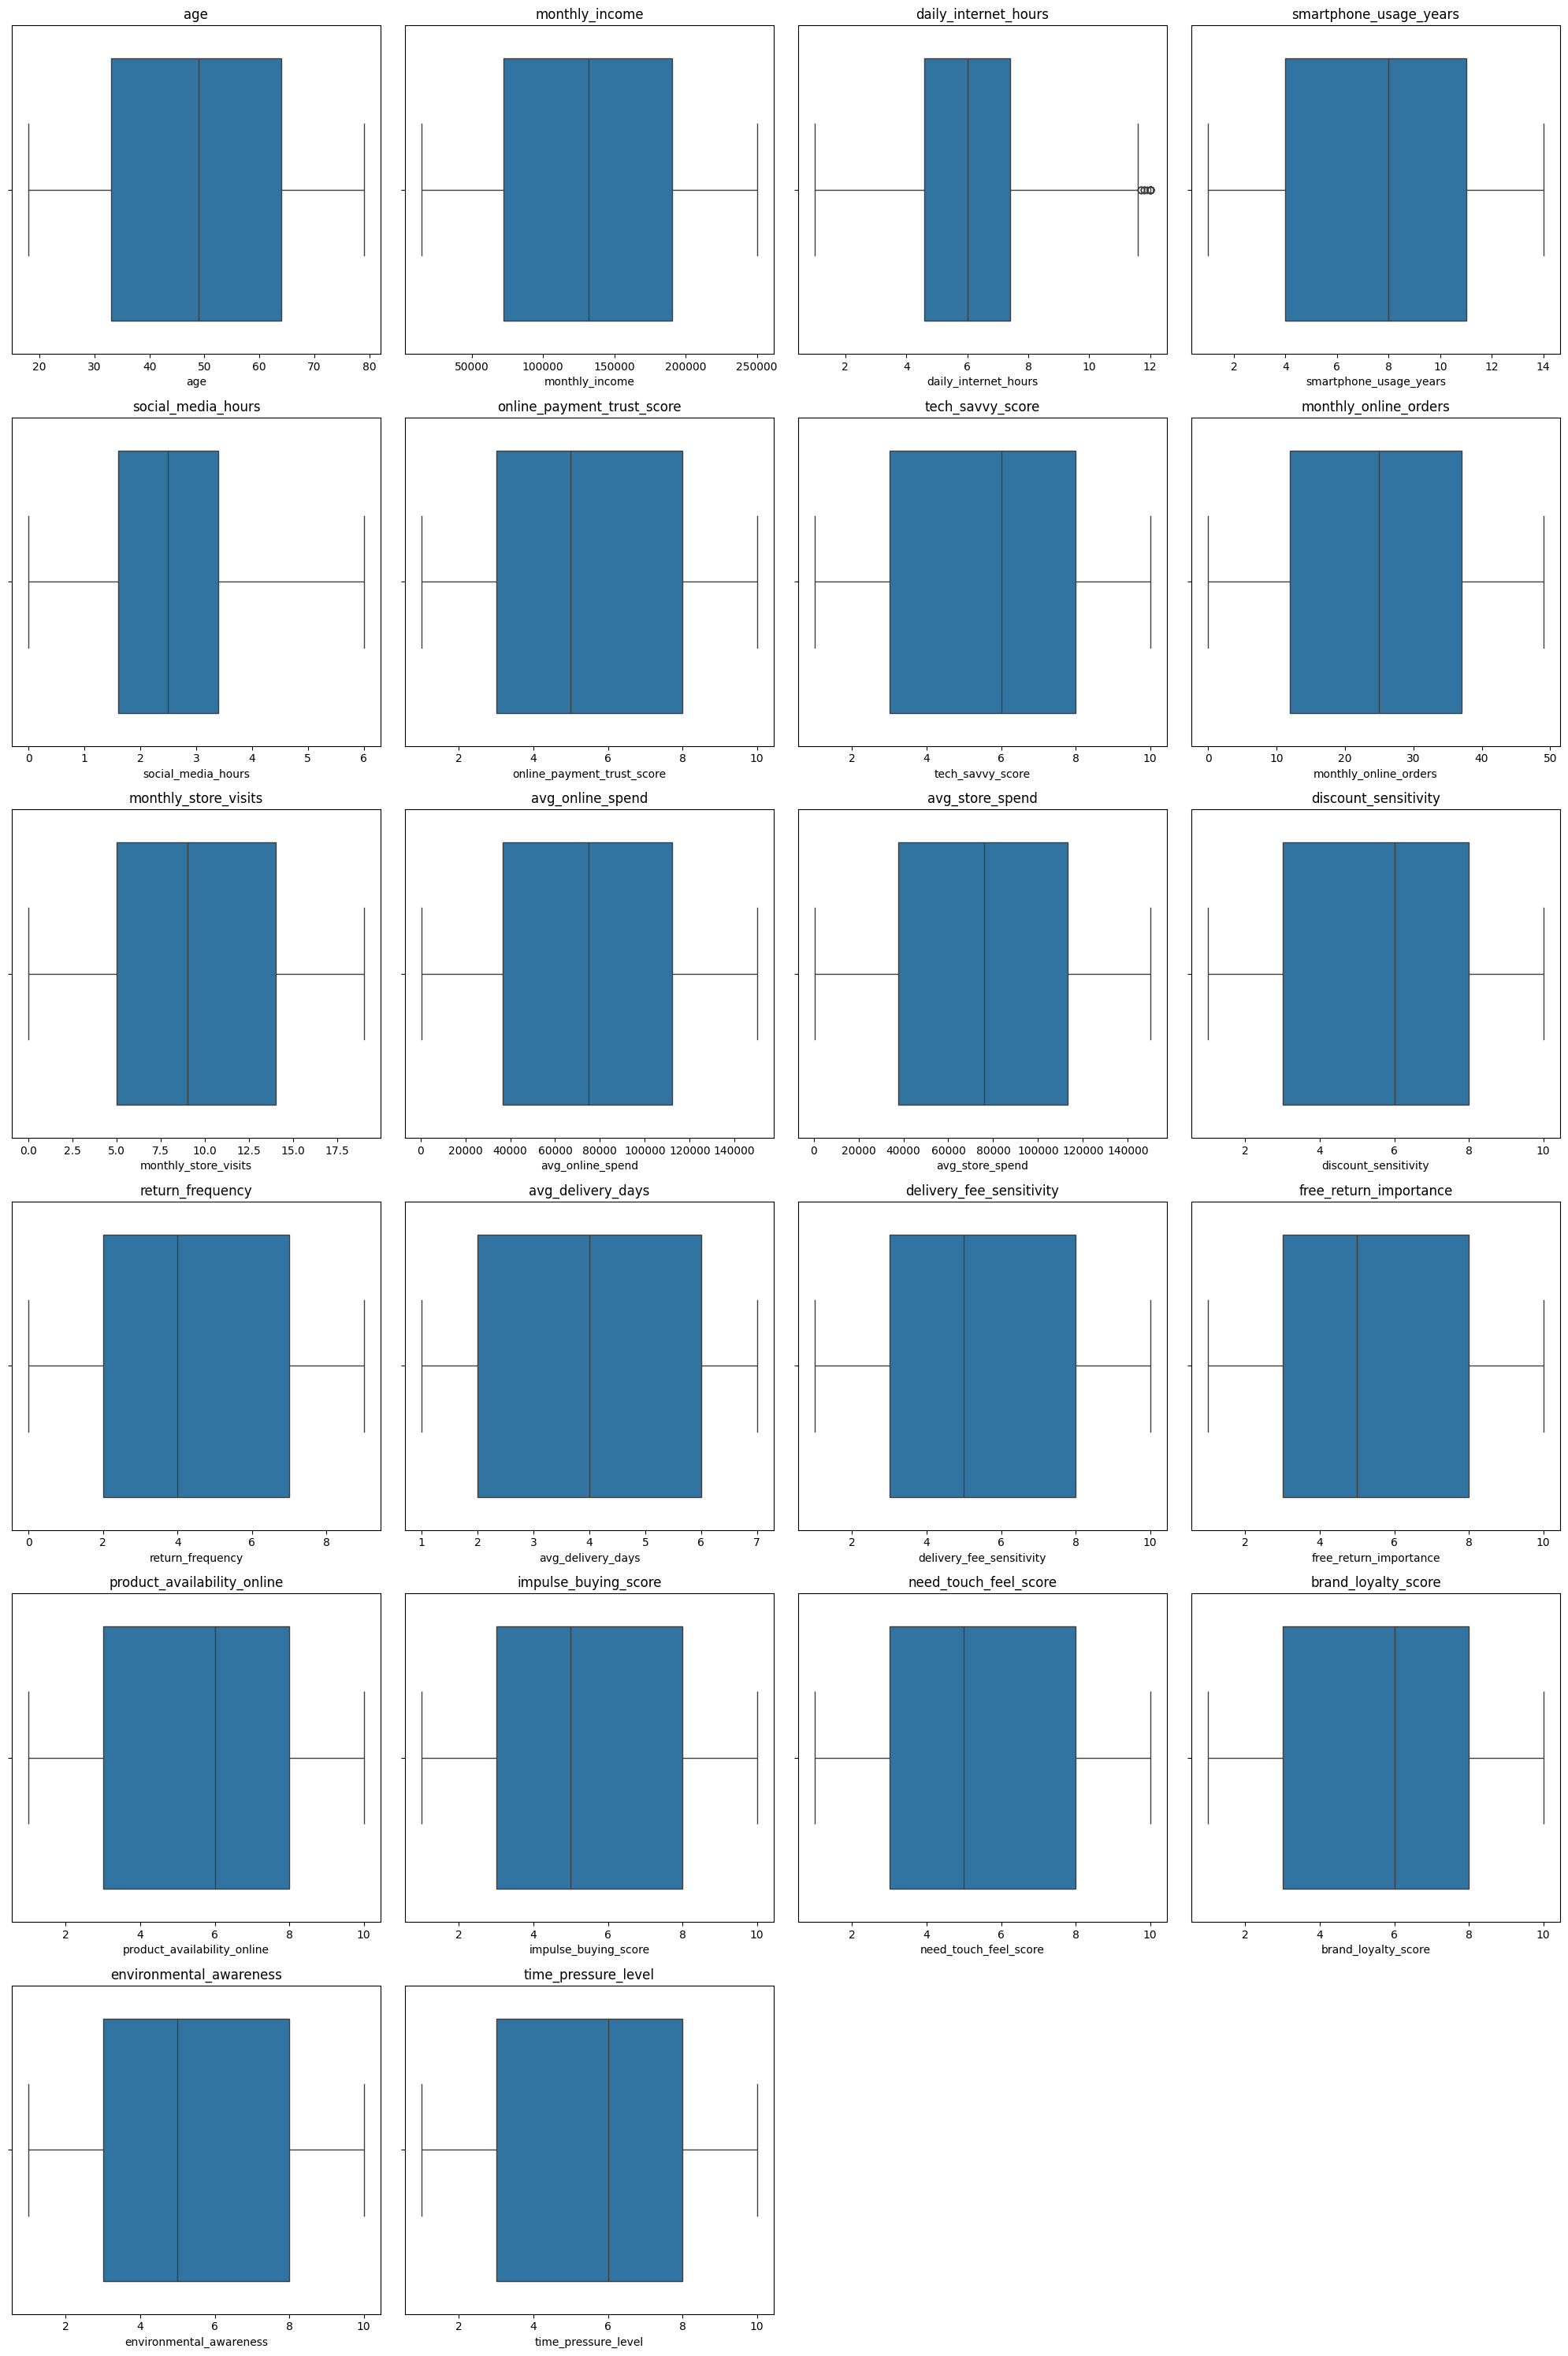

In [12]:
num_cols = df.select_dtypes(include=np.number).columns
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)
    
plt.tight_layout()
plt.show()

# Processing Data

## Pisahkan Terget

In [13]:
mapping = {
    'Store':0,
    'Online':1,
    'Hybrid':2
}

y = df['shopping_preference'].map(mapping)

In [14]:
X = df.drop(columns=['shopping_preference'])
X = pd.get_dummies(X, drop_first=True)

## Split Data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Class Weight Untuk Imbalance data

In [16]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
sample_weights = y_train.map(class_weights)

# Model XGBoost

In [17]:
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

In [18]:
model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

## Tuning Parametr

In [19]:
model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

param_grid = {
    'n_estimators': [200,300,400],
    'max_depth': [4,6,8,10],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,0.8,0.9,1],
    'colsample_bytree': [0.7,0.8,0.9,1],
    'gamma': [0,0.1,0.2],
    'min_child_weight': [1,3,5]
}

search = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=30,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

search.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

best_model = search.best_estimator_

print("Best Parameters:", search.best_params_)
print("Best CV Score:", search.best_score_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV Score: 0.7757719387123465


## Testing & Evaluasi

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2049
           1       0.91      0.93      0.92       235
           2       0.41      0.51      0.46        74

    accuracy                           0.96      2358
   macro avg       0.77      0.81      0.79      2358
weighted avg       0.97      0.96      0.96      2358

F1 Macro: 0.7881
F1 Weighted: 0.9631


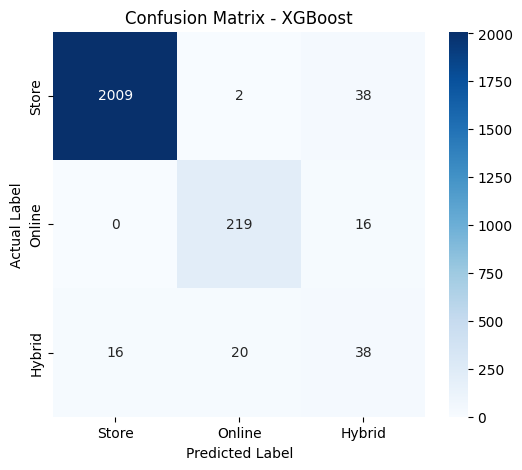

In [20]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))


f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("F1 Macro:", round(f1_macro,4))
print("F1 Weighted:", round(f1_weighted,4))

cm = confusion_matrix(y_test, y_pred)
labels = ["Store", "Online", "Hybrid"]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [21]:
joblib.dump(best_model, "model_xgboost.pkl")

['model_xgboost.pkl']

## Feature Importance

                        feature  importance
10              avg_store_spend    0.226869
18        need_touch_feel_score    0.071156
6              tech_savvy_score    0.062514
7         monthly_online_orders    0.055364
8          monthly_store_visits    0.046426
5    online_payment_trust_score    0.043232
24             city_tier_Tier 2    0.038422
16  product_availability_online    0.035613
2          daily_internet_hours    0.033607
1                monthly_income    0.028653
9              avg_online_spend    0.028165
22                  gender_Male    0.025664
19          brand_loyalty_score    0.025517
20      environmental_awareness    0.025445
15       free_return_importance    0.024913
3        smartphone_usage_years    0.024499
14     delivery_fee_sensitivity    0.023370
4            social_media_hours    0.023336
0                           age    0.021871
17         impulse_buying_score    0.021869
23                 gender_Other    0.020416
11         discount_sensitivity 

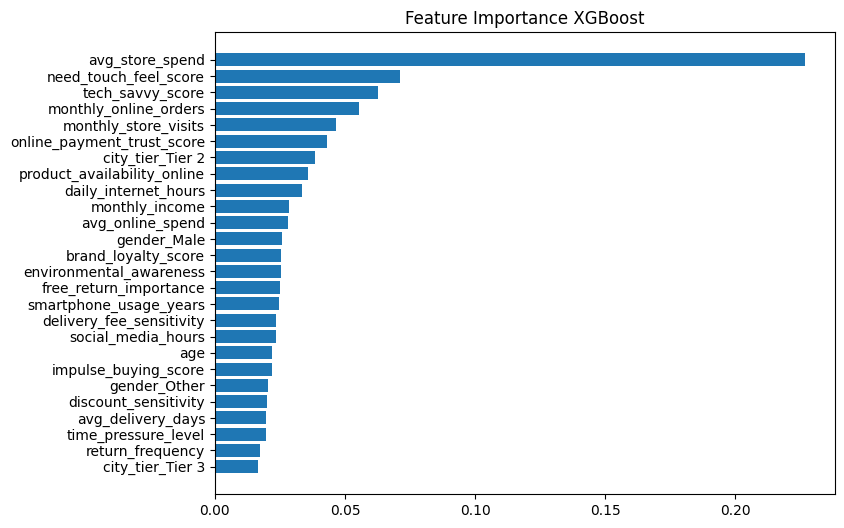

In [22]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8,6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance XGBoost")
plt.show()

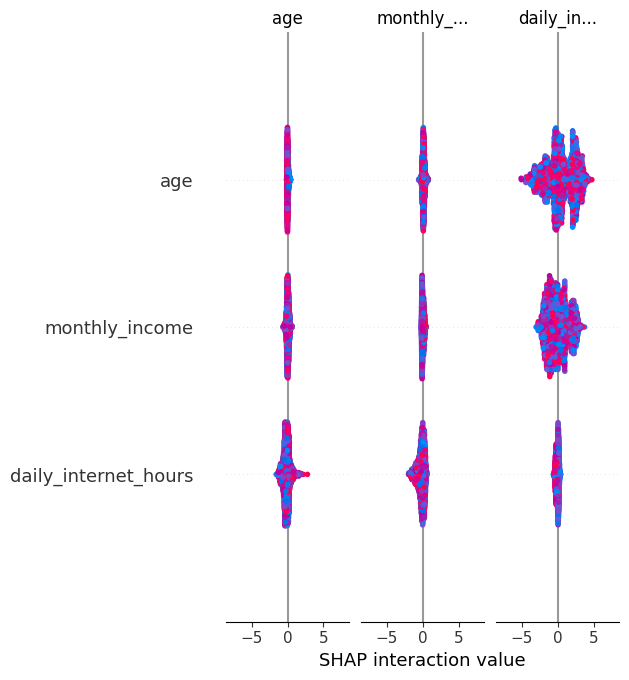

In [23]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

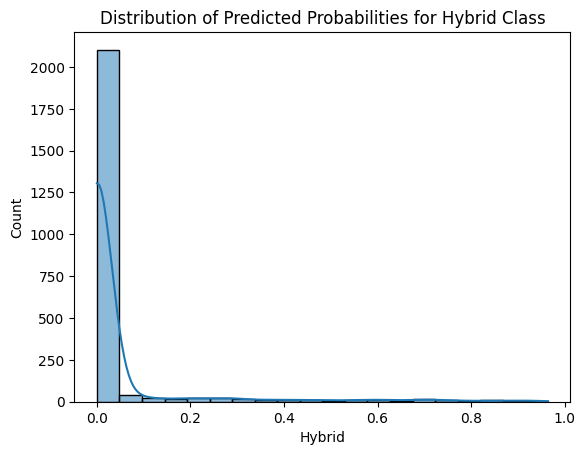

In [24]:
y_proba = best_model.predict_proba(X_test)
df_proba = pd.DataFrame(y_proba, columns=labels)

# Plot distribusi probabilitas Hybrid
sns.histplot(df_proba['Hybrid'], bins=20, kde=True)
plt.title("Distribution of Predicted Probabilities for Hybrid Class")
plt.show()